In [2]:
# ============================================================
# RSNA Knee Abnormality Detection
# 58 GOLD-LABELED STUDIES - DATASET-LEVEL MRI EDA
# ============================================================

import os
import re
import json
import math
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import pydicom
except ImportError:
    !pip install -q pydicom
    import pydicom

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_ROOT = (
    "/kaggle/input/competitions/"
    "rsna-knee-abnormality-detection"
)

TRAIN_CSV = os.path.join(
    DATA_ROOT,
    "train.csv"
)

TRAIN_SERIES_ROOT = os.path.join(
    DATA_ROOT,
    "train_series"
)

OUTPUT_DIR = "./rsna_58_labeled_analysis"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


LABEL_COLUMNS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

In [3]:
# ============================================================
# 2. LOAD TRAIN.CSV
# ============================================================

train = pd.read_csv(TRAIN_CSV)

print("=" * 90)
print("TRAIN DATASET")
print("=" * 90)

print(
    f"Rows:    {len(train):,}"
)

print(
    f"Columns: {len(train.columns)}"
)


# ------------------------------------------------------------
# Identify fully labeled studies
# ------------------------------------------------------------

fully_labeled_mask = (
    train[LABEL_COLUMNS]
    .notna()
    .all(axis=1)
)

labeled_df = (
    train.loc[
        fully_labeled_mask
    ]
    .copy()
)


print(
    f"\nFully labeled studies: "
    f"{len(labeled_df):,}"
)

print(
    f"Unlabeled studies: "
    f"{len(train) - len(labeled_df):,}"
)


# Safety check
if len(labeled_df) == 0:

    raise RuntimeError(
        "No fully labeled studies found."
    )


TRAIN DATASET
Rows:    4,407
Columns: 14

Fully labeled studies: 58
Unlabeled studies: 4,349


In [4]:
# ============================================================
# 3. LABEL SUMMARY
# ============================================================

label_summary = []

for label in LABEL_COLUMNS:

    positive = int(
        (labeled_df[label] == 1).sum()
    )

    negative = int(
        (labeled_df[label] == 0).sum()
    )

    total = positive + negative

    prevalence = (
        positive / total
        if total > 0
        else np.nan
    )

    label_summary.append(
        {
            "Label": label,
            "Positive": positive,
            "Negative": negative,
            "Total": total,
            "Prevalence": prevalence
        }
    )

label_summary_df = pd.DataFrame(
    label_summary
)

label_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "label_summary.csv"
    ),
    index=False
)

In [5]:
# ============================================================
# 4. LABEL CO-OCCURRENCE
# ============================================================

label_matrix = (
    labeled_df[LABEL_COLUMNS]
    .astype(int)
)

cooccurrence_counts = (
    label_matrix.T
    .dot(label_matrix)
)

cooccurrence_counts.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "label_cooccurrence_counts.csv"
    )
)


# Pairwise Jaccard-like overlap
cooccurrence_ratio = pd.DataFrame(
    index=LABEL_COLUMNS,
    columns=LABEL_COLUMNS,
    dtype=float
)

for a in LABEL_COLUMNS:

    for b in LABEL_COLUMNS:

        intersection = int(
            (
                (label_matrix[a] == 1)
                &
                (label_matrix[b] == 1)
            ).sum()
        )

        union = int(
            (
                (label_matrix[a] == 1)
                |
                (label_matrix[b] == 1)
            ).sum()
        )

        if union == 0:
            value = np.nan
        else:
            value = intersection / union

        cooccurrence_ratio.loc[a, b] = value


cooccurrence_ratio.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "label_jaccard_overlap.csv"
    )
)

In [6]:
# ============================================================
# 5. DICOM HELPERS
# ============================================================

def safe_value(ds, attribute, default=None):

    value = getattr(
        ds,
        attribute,
        default
    )

    if value is None:
        return default

    try:

        if isinstance(
            value,
            pydicom.multival.MultiValue
        ):

            result = []

            for x in value:

                try:
                    result.append(float(x))
                except Exception:
                    result.append(str(x))

            return result


        if isinstance(
            value,
            (list, tuple)
        ):

            result = []

            for x in value:

                try:
                    result.append(float(x))
                except Exception:
                    result.append(str(x))

            return result


        if isinstance(
            value,
            np.integer
        ):

            return int(value)


        if isinstance(
            value,
            np.floating
        ):

            return float(value)


        return str(value)

    except Exception:

        return str(value)


def get_slice_position(ds):

    orientation = getattr(
        ds,
        "ImageOrientationPatient",
        None
    )

    position = getattr(
        ds,
        "ImagePositionPatient",
        None
    )

    if orientation is None:
        return None

    if position is None:
        return None

    try:

        row = np.asarray(
            orientation[:3],
            dtype=float
        )

        col = np.asarray(
            orientation[3:],
            dtype=float
        )

        normal = np.cross(
            row,
            col
        )

        position = np.asarray(
            position,
            dtype=float
        )

        return float(
            np.dot(
                position,
                normal
            )
        )

    except Exception:

        return None


# ------------------------------------------------------------
# Determine coarse anatomical plane
# ------------------------------------------------------------

def infer_plane_from_orientation(ds):

    orientation = getattr(
        ds,
        "ImageOrientationPatient",
        None
    )

    if orientation is None:
        return "Unknown"

    try:

        row = np.asarray(
            orientation[:3],
            dtype=float
        )

        col = np.asarray(
            orientation[3:],
            dtype=float
        )

        normal = np.abs(
            np.cross(row, col)
        )

        dominant_axis = int(
            np.argmax(normal)
        )

        # DICOM patient coordinates:
        # x = Left/Right
        # y = Posterior/Anterior
        # z = Inferior/Superior
        #
        # Normal approximately:
        # x -> sagittal
        # y -> coronal
        # z -> axial

        if dominant_axis == 0:
            return "Sagittal"

        if dominant_axis == 1:
            return "Coronal"

        if dominant_axis == 2:
            return "Axial"

        return "Unknown"

    except Exception:

        return "Unknown"


# ------------------------------------------------------------
# Infer sequence characteristics from description
# ------------------------------------------------------------

def infer_sequence_features(description):

    text = (
        str(description)
        .lower()
    )

    return {

        "Is_PD":
            int(
                "pd" in text
            ),

        "Is_T1":
            int(
                re.search(
                    r"(^|[_\-\s])t1([_\-\s]|$)",
                    text
                )
                is not None
            ),

        "Is_T2":
            int(
                re.search(
                    r"(^|[_\-\s])t2([_\-\s]|$)",
                    text
                )
                is not None
            ),

        "Is_Fat_Suppressed":
            int(
                any(
                    x in text
                    for x in [
                        "fs",
                        "fat_suppress",
                        "fat suppression",
                        "spir",
                        "stir"
                    ]
                )
            ),

        "Is_Sagittal":
            int(
                re.search(
                    r"(^|[_\-\s])(sag|sagittal)([_\-\s]|$)",
                    text
                )
                is not None
            ),

        "Is_Coronal":
            int(
                re.search(
                    r"(^|[_\-\s])(cor|coronal)([_\-\s]|$)",
                    text
                )
                is not None
            ),

        "Is_Axial":
            int(
                re.search(
                    r"(^|[_\-\s])(tra|ax|axial)([_\-\s]|$)",
                    text
                )
                is not None
            )
    }


In [7]:

# ============================================================
# 6. INSPECT EVERY LABELED STUDY / SERIES
# ============================================================

study_records = []
series_records = []

failed_series = []

print("\n" + "=" * 90)
print("SCANNING LABELED STUDIES")
print("=" * 90)


for study_idx, (_, study_row) in enumerate(
    labeled_df.iterrows(),
    start=1
):

    study_uid = (
        str(
            study_row[
                "StudyInstanceUID"
            ]
        )
    )

    study_dir = os.path.join(
        TRAIN_SERIES_ROOT,
        study_uid
    )

    if not os.path.isdir(study_dir):

        print(
            f"[WARNING] Study directory missing: "
            f"{study_uid}"
        )

        continue


    series_dirs = sorted(
        [
            p
            for p in glob.glob(
                os.path.join(
                    study_dir,
                    "*"
                )
            )
            if os.path.isdir(p)
        ]
    )


    total_slices = 0

    series_count = 0

    study_planes = set()

    study_manufacturers = set()

    study_models = set()

    field_strengths = set()

    series_descriptions = []

    sequence_names = []


    # --------------------------------------------------------
    # Process each series
    # --------------------------------------------------------

    for series_index, series_dir in enumerate(
        series_dirs,
        start=1
    ):

        series_uid = os.path.basename(
            series_dir
        )

        dicom_paths = sorted(
            glob.glob(
                os.path.join(
                    series_dir,
                    "*.dcm"
                )
            )
        )

        if len(dicom_paths) == 0:

            failed_series.append(
                {
                    "StudyInstanceUID":
                        study_uid,

                    "SeriesInstanceUID":
                        series_uid,

                    "Reason":
                        "No DICOM files"
                }
            )

            continue


        # ----------------------------------------------------
        # Read first DICOM
        # ----------------------------------------------------

        try:

            first_ds = pydicom.dcmread(
                dicom_paths[0],
                stop_before_pixels=True,
                force=True
            )

        except Exception as e:

            failed_series.append(
                {
                    "StudyInstanceUID":
                        study_uid,

                    "SeriesInstanceUID":
                        series_uid,

                    "Reason":
                        str(e)
                }
            )

            continue


        # ----------------------------------------------------
        # Read all headers for spatial consistency
        # ----------------------------------------------------

        positions = []

        dimensions = []

        for path in dicom_paths:

            try:

                ds = pydicom.dcmread(
                    path,
                    stop_before_pixels=True,
                    force=True
                )

                dimensions.append(
                    (
                        int(
                            getattr(
                                ds,
                                "Rows",
                                0
                            )
                        ),

                        int(
                            getattr(
                                ds,
                                "Columns",
                                0
                            )
                        )
                    )
                )

                positions.append(
                    get_slice_position(ds)
                )

            except Exception:

                dimensions.append(
                    None
                )

                positions.append(
                    None
                )


        valid_positions = [
            x
            for x in positions
            if x is not None
        ]


        if len(valid_positions) > 1:

            diffs = np.diff(
                sorted(
                    valid_positions
                )
            )

            median_spacing = float(
                np.median(
                    np.abs(diffs)
                )
            )

        else:

            median_spacing = None


        description = safe_value(
            first_ds,
            "SeriesDescription"
        )

        sequence_name = safe_value(
            first_ds,
            "SequenceName"
        )

        manufacturer = safe_value(
            first_ds,
            "Manufacturer"
        )

        model = safe_value(
            first_ds,
            "ManufacturerModelName"
        )

        field_strength = safe_value(
            first_ds,
            "MagneticFieldStrength"
        )

        plane = infer_plane_from_orientation(
            first_ds
        )


        sequence_features = (
            infer_sequence_features(
                description
            )
        )


        # ----------------------------------------------------
        # Aggregate study-level properties
        # ----------------------------------------------------

        total_slices += len(
            dicom_paths
        )

        series_count += 1

        study_planes.add(
            plane
        )

        if manufacturer:
            study_manufacturers.add(
                manufacturer
            )

        if model:
            study_models.add(
                model
            )

        if field_strength:
            field_strengths.add(
                field_strength
            )

        if description:
            series_descriptions.append(
                description
            )

        if sequence_name:
            sequence_names.append(
                sequence_name
            )


        # ----------------------------------------------------
        # Series record
        # ----------------------------------------------------

        record = {

            "StudyInstanceUID":
                study_uid,

            "SeriesIndex":
                series_index,

            "SeriesInstanceUID":
                series_uid,

            "NumberOfSlices":
                len(dicom_paths),

            "Rows":
                safe_value(
                    first_ds,
                    "Rows"
                ),

            "Columns":
                safe_value(
                    first_ds,
                    "Columns"
                ),

            "PixelSpacing":
                str(
                    safe_value(
                        first_ds,
                        "PixelSpacing"
                    )
                ),

            "SliceThickness":
                safe_value(
                    first_ds,
                    "SliceThickness"
                ),

            "SpacingBetweenSlices":
                safe_value(
                    first_ds,
                    "SpacingBetweenSlices"
                ),

            "ComputedMedianSliceSpacing":
                median_spacing,

            "ImageOrientationPatient":
                str(
                    safe_value(
                        first_ds,
                        "ImageOrientationPatient"
                    )
                ),

            "AnatomicalPlane":
                plane,

            "SeriesDescription":
                description,

            "SequenceName":
                sequence_name,

            "ScanningSequence":
                safe_value(
                    first_ds,
                    "ScanningSequence"
                ),

            "SequenceVariant":
                str(
                    safe_value(
                        first_ds,
                        "SequenceVariant"
                    )
                ),

            "Manufacturer":
                manufacturer,

            "ManufacturerModelName":
                model,

            "MagneticFieldStrength":
                field_strength,

            "EchoTime":
                safe_value(
                    first_ds,
                    "EchoTime"
                ),

            "RepetitionTime":
                safe_value(
                    first_ds,
                    "RepetitionTime"
                ),

            "FlipAngle":
                safe_value(
                    first_ds,
                    "FlipAngle"
                ),

            "Is_PD":
                sequence_features[
                    "Is_PD"
                ],

            "Is_T1":
                sequence_features[
                    "Is_T1"
                ],

            "Is_T2":
                sequence_features[
                    "Is_T2"
                ],

            "Is_Fat_Suppressed":
                sequence_features[
                    "Is_Fat_Suppressed"
                ],

            "Is_Sagittal":
                sequence_features[
                    "Is_Sagittal"
                ],

            "Is_Coronal":
                sequence_features[
                    "Is_Coronal"
                ],

            "Is_Axial":
                sequence_features[
                    "Is_Axial"
                ]
        }


        series_records.append(
            record
        )


    # ========================================================
    # Study-level availability flags
    # ========================================================

    study_series_subset = [
        x
        for x in series_records
        if x[
            "StudyInstanceUID"
        ] == study_uid
    ]


    def count_flag(flag):

        return int(
            sum(
                x.get(flag, 0)
                for x in study_series_subset
            )
        )


    study_record = {

        "StudyInstanceUID":
            study_uid,

        "NumberOfSeries":
            series_count,

        "TotalSlices":
            total_slices,

        "NumberOfSagittalSeries":
            sum(
                x["AnatomicalPlane"]
                == "Sagittal"
                for x in study_series_subset
            ),

        "NumberOfCoronalSeries":
            sum(
                x["AnatomicalPlane"]
                == "Coronal"
                for x in study_series_subset
            ),

        "NumberOfAxialSeries":
            sum(
                x["AnatomicalPlane"]
                == "Axial"
                for x in study_series_subset
            ),

        "HasSagittal":
            int(
                "Sagittal"
                in study_planes
            ),

        "HasCoronal":
            int(
                "Coronal"
                in study_planes
            ),

        "HasAxial":
            int(
                "Axial"
                in study_planes
            ),

        "NumberOfPDSeries":
            count_flag("Is_PD"),

        "NumberOfT1Series":
            count_flag("Is_T1"),

        "NumberOfT2Series":
            count_flag("Is_T2"),

        "NumberOfFatSuppressedSeries":
            count_flag(
                "Is_Fat_Suppressed"
            ),

        "Manufacturers":
            "|".join(
                sorted(
                    study_manufacturers
                )
            ),

        "ScannerModels":
            "|".join(
                sorted(
                    study_models
                )
            ),

        "FieldStrengths":
            "|".join(
                sorted(
                    field_strengths
                )
            ),

        "SeriesDescriptions":
            " | ".join(
                series_descriptions
            ),

        "SequenceNames":
            " | ".join(
                sequence_names
            ),

        # ----------------------------------------------------
        # Report information
        # ----------------------------------------------------

        "ReportPresent":
            int(
                pd.notna(
                    study_row[
                        "Report"
                    ]
                )
            ),

        "ReportCharacterCount":
            len(
                str(
                    study_row[
                        "Report"
                    ]
                )
            )
            if pd.notna(
                study_row[
                    "Report"
                ]
            )
            else 0
    }


    # --------------------------------------------------------
    # Add all 12 labels
    # --------------------------------------------------------

    for label in LABEL_COLUMNS:

        study_record[label] = int(
            study_row[label]
        )


    study_records.append(
        study_record
    )


    print(
        f"{study_idx:02d}/{len(labeled_df)} | "
        f"Series={series_count:2d} | "
        f"Slices={total_slices:4d} | "
        f"Study={study_uid}"
    )



SCANNING LABELED STUDIES
01/58 | Series= 5 | Slices= 164 | Study=1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
02/58 | Series= 9 | Slices= 273 | Study=1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269
03/58 | Series= 7 | Slices= 212 | Study=1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052
04/58 | Series= 5 | Slices= 113 | Study=1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580
05/58 | Series= 9 | Slices= 233 | Study=1.2.826.0.1.3680043.8.498.11382021393803389951964005983002209238
06/58 | Series= 9 | Slices= 275 | Study=1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935
07/58 | Series= 6 | Slices= 190 | Study=1.2.826.0.1.3680043.8.498.11557620559191469069130827959098335840
08/58 | Series= 5 | Slices= 122 | Study=1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756
09/58 | Series= 5 | Slices= 192 | Study=1.2.826.0.1.3680043.8.498.11851412923016044948101698015974810604
10/58 | Series= 4 | Slices= 1

In [8]:

# ============================================================
# 7. CREATE DATAFRAMES
# ============================================================

study_metadata_df = pd.DataFrame(
    study_records
)

series_metadata_df = pd.DataFrame(
    series_records
)

failed_series_df = pd.DataFrame(
    failed_series
)


In [9]:

# ============================================================
# 8. SAVE CSV FILES
# ============================================================

study_metadata_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "labeled_studies_metadata.csv"
    ),
    index=False
)

series_metadata_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "labeled_series_metadata.csv"
    ),
    index=False
)

label_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "label_summary.csv"
    ),
    index=False
)

if len(failed_series_df) > 0:

    failed_series_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "failed_series.csv"
        ),
        index=False
    )


In [10]:

# ============================================================
# 9. DATASET LEVEL SUMMARY
# ============================================================

summary = {

    "dataset": {

        "total_train_studies":
            int(len(train)),

        "fully_labeled_studies":
            int(len(labeled_df)),

        "unlabeled_studies":
            int(
                len(train)
                - len(labeled_df)
            )
    },


    "series": {

        "total_series_across_labeled_studies":
            int(
                len(series_metadata_df)
            ),

        "total_slices_across_labeled_studies":
            int(
                series_metadata_df[
                    "NumberOfSlices"
                ].sum()
            ),

        "series_per_study": {

            "mean":
                float(
                    study_metadata_df[
                        "NumberOfSeries"
                    ].mean()
                ),

            "median":
                float(
                    study_metadata_df[
                        "NumberOfSeries"
                    ].median()
                ),

            "min":
                int(
                    study_metadata_df[
                        "NumberOfSeries"
                    ].min()
                ),

            "max":
                int(
                    study_metadata_df[
                        "NumberOfSeries"
                    ].max()
                )
        },

        "slices_per_study": {

            "mean":
                float(
                    study_metadata_df[
                        "TotalSlices"
                    ].mean()
                ),

            "median":
                float(
                    study_metadata_df[
                        "TotalSlices"
                    ].median()
                ),

            "min":
                int(
                    study_metadata_df[
                        "TotalSlices"
                    ].min()
                ),

            "max":
                int(
                    study_metadata_df[
                        "TotalSlices"
                    ].max()
                )
        }
    },


    "anatomical_planes": {

        "series_counts":
            series_metadata_df[
                "AnatomicalPlane"
            ]
            .value_counts()
            .to_dict(),

        "study_has_sagittal":
            int(
                study_metadata_df[
                    "HasSagittal"
                ].sum()
            ),

        "study_has_coronal":
            int(
                study_metadata_df[
                    "HasCoronal"
                ].sum()
            ),

        "study_has_axial":
            int(
                study_metadata_df[
                    "HasAxial"
                ].sum()
            )
    },


    "scanner": {

        "manufacturers":
            series_metadata_df[
                "Manufacturer"
            ]
            .value_counts()
            .to_dict(),

        "scanner_models":
            series_metadata_df[
                "ManufacturerModelName"
            ]
            .value_counts()
            .to_dict(),

        "field_strengths":
            series_metadata_df[
                "MagneticFieldStrength"
            ]
            .value_counts()
            .to_dict()
    },


    "series_descriptions":
        series_metadata_df[
            "SeriesDescription"
        ]
        .value_counts()
        .to_dict(),


    "sequence_flags": {

        "PD_series":
            int(
                series_metadata_df[
                    "Is_PD"
                ].sum()
            ),

        "T1_series":
            int(
                series_metadata_df[
                    "Is_T1"
                ].sum()
            ),

        "T2_series":
            int(
                series_metadata_df[
                    "Is_T2"
                ].sum()
            ),

        "fat_suppressed_series":
            int(
                series_metadata_df[
                    "Is_Fat_Suppressed"
                ].sum()
            )
    },


    "labels": {

        "positive_counts":
            {
                label: int(
                    (
                        labeled_df[label]
                        == 1
                    ).sum()
                )
                for label in LABEL_COLUMNS
            },

        "negative_counts":
            {
                label: int(
                    (
                        labeled_df[label]
                        == 0
                    ).sum()
                )
                for label in LABEL_COLUMNS
            },

        "prevalence":
            {
                label: float(
                    labeled_df[label].mean()
                )
                for label in LABEL_COLUMNS
            }
    }
}

In [12]:

# ============================================================
# 10. SAVE JSON SUMMARY
# ============================================================

with open(
    os.path.join(
        OUTPUT_DIR,
        "labeled_dataset_summary.json"
    ),
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        default=str
    )


In [13]:

# ============================================================
# 11. SAVE LABEL CO-OCCURRENCE
# ============================================================

label_matrix = (
    labeled_df[
        LABEL_COLUMNS
    ]
    .astype(int)
)

cooccurrence = (
    label_matrix.T
    .dot(
        label_matrix
    )
)

cooccurrence.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "label_cooccurrence.csv"
    )
)

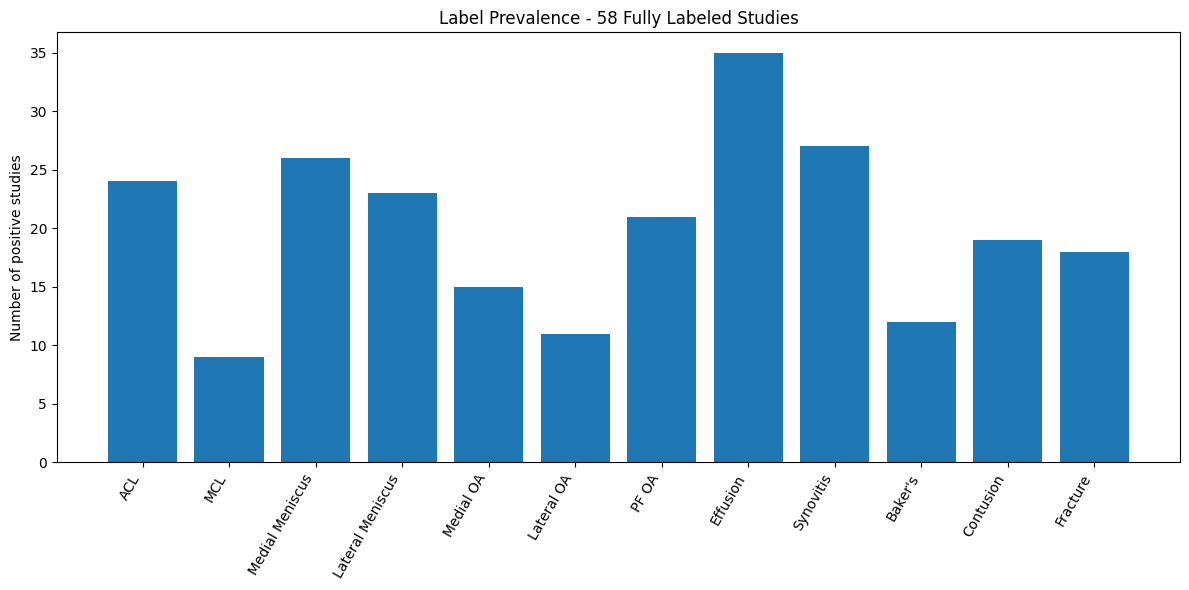

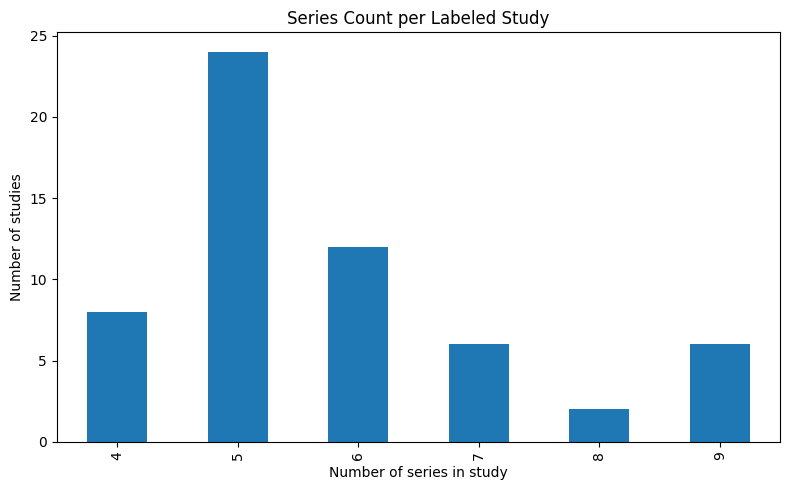

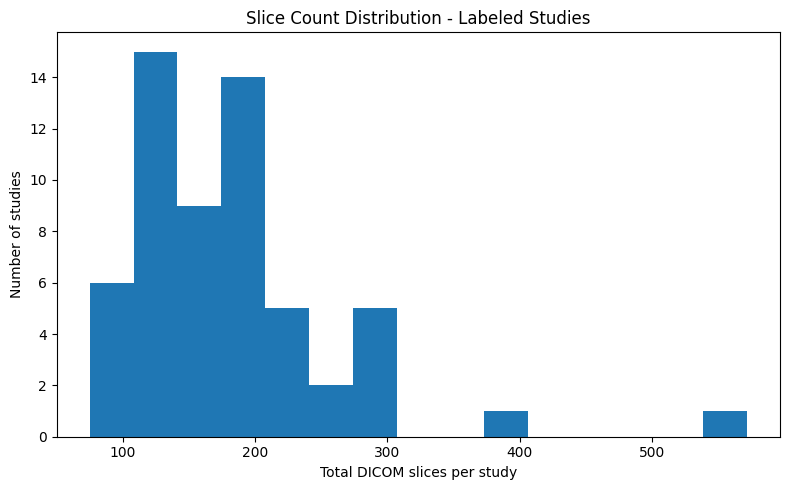

In [14]:

# ============================================================
# 12. PLOTS
# ============================================================

# ------------------------------------------------------------
# Label prevalence
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    LABEL_COLUMNS,
    [
        summary["labels"]
        ["positive_counts"]
        [label]
        for label in LABEL_COLUMNS
    ]
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel(
    "Number of positive studies"
)

plt.title(
    "Label Prevalence - 58 Fully Labeled Studies"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "label_prevalence.png"
    ),
    dpi=200
)

plt.show()


# ------------------------------------------------------------
# Number of series per study
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

study_metadata_df[
    "NumberOfSeries"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel(
    "Number of series in study"
)

plt.ylabel(
    "Number of studies"
)

plt.title(
    "Series Count per Labeled Study"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "series_count_distribution.png"
    ),
    dpi=200
)

plt.show()


# ------------------------------------------------------------
# Total slices per study
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    study_metadata_df[
        "TotalSlices"
    ],
    bins=15
)

plt.xlabel(
    "Total DICOM slices per study"
)

plt.ylabel(
    "Number of studies"
)

plt.title(
    "Slice Count Distribution - Labeled Studies"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "slice_count_distribution.png"
    ),
    dpi=200
)

plt.show()

In [15]:

# ============================================================
# 13. PRINT KEY FINDINGS
# ============================================================

print("\n")
print("=" * 90)
print("FINAL DATASET SUMMARY")
print("=" * 90)

print(
    f"\nTotal train studies       : "
    f"{len(train):,}"
)

print(
    f"Fully labeled studies    : "
    f"{len(labeled_df):,}"
)

print(
    f"Unlabeled studies        : "
    f"{len(train) - len(labeled_df):,}"
)

print(
    f"\nTotal series in labeled "
    f"studies                 : "
    f"{len(series_metadata_df):,}"
)

print(
    f"Total DICOM slices       : "
    f"{int(series_metadata_df['NumberOfSlices'].sum()):,}"
)


print("\nLabel prevalence:")

for label in LABEL_COLUMNS:

    positive = summary[
        "labels"
    ][
        "positive_counts"
    ][
        label
    ]

    prevalence = summary[
        "labels"
    ][
        "prevalence"
    ][
        label
    ]

    print(
        f"  {label:20s}: "
        f"{positive:2d}/58 "
        f"({prevalence:.1%})"
    )


print("\nSeries descriptions:")

print(
    series_metadata_df[
        "SeriesDescription"
    ]
    .value_counts()
    .to_string()
)


print("\nAnatomical planes:")

print(
    series_metadata_df[
        "AnatomicalPlane"
    ]
    .value_counts()
    .to_string()
)


print("\nManufacturers:")

print(
    series_metadata_df[
        "Manufacturer"
    ]
    .value_counts()
    .to_string()
)


print("\nOutput directory:")
print(
    os.path.abspath(
        OUTPUT_DIR
    )
)

print("\nDONE.")



FINAL DATASET SUMMARY

Total train studies       : 4,407
Fully labeled studies    : 58
Unlabeled studies        : 4,349

Total series in labeled studies                 : 336
Total DICOM slices       : 10,528

Label prevalence:
  ACL                 : 24/58 (41.4%)
  MCL                 :  9/58 (15.5%)
  Medial Meniscus     : 26/58 (44.8%)
  Lateral Meniscus    : 23/58 (39.7%)
  Medial OA           : 15/58 (25.9%)
  Lateral OA          : 11/58 (19.0%)
  PF OA               : 21/58 (36.2%)
  Effusion            : 35/58 (60.3%)
  Synovitis           : 27/58 (46.6%)
  Baker's             : 12/58 (20.7%)
  Contusion           : 19/58 (32.8%)
  Fracture            : 18/58 (31.0%)

Series descriptions:
SeriesDescription
DummySeriesDesc!                      21
t1_se_cor_384                          7
PDW_TSE_Sag                            7
pd_tse_fs_tra_320                      6
pd_tse_fs_cor_320                      5
pd_tse_fs_sag_320                      5
RT.Tra_T1W_TSE              